<a href="https://colab.research.google.com/github/beebzo6/CALCULATOR-APP/blob/main/CHAPTER3_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
X,y=mnist['data'],mnist['target']
print(f'{X.shape} {y.shape}')

(70000, 784) (70000,)


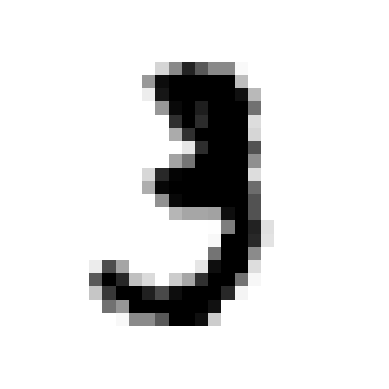

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit = X.iloc[10]
some_digit_image = some_digit.values.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [4]:
y[0]

'5'

In [5]:
import numpy as np

y=y.astype(np.uint8)

In [6]:
X_train,X_test,y_train,y_test=X[:60000],X[60000:],y[:60000],y[60000:]

In [7]:
y_train_5=(y_train==5)
y_test_5=(y_test==5)

In [8]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

In [9]:
sgd_clf.predict([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([False])

In [10]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [11]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self,X,y=None):
        pass
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)

In [12]:
 never_5_clf = Never5Classifier()

cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

In [13]:
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)

In [14]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [15]:
y_train_prefect_predicions=y_train_5
confusion_matrix( y_train_5,y_train_prefect_predicions)

array([[54579,     0],
       [    0,  5421]])

In [16]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5,y_train_pred)

0.8370879772350012

In [17]:
recall_score(y_train_5,y_train_pred)

0.6511713705958311

In [18]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [19]:
y_scores=sgd_clf.decision_function([some_digit])
y_scores

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([-5711.47789687])

In [20]:
threshold=8000000000
y_some_digit_pred=(y_scores>threshold)

In [21]:
y_some_digit_pred

array([False])

In [22]:
threshold=4000000000
y_some_digit_pred=(y_scores>threshold)
y_some_digit_pred


array([False])

In [23]:
y_scores=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3,method='decision_function')

In [24]:
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_scores)

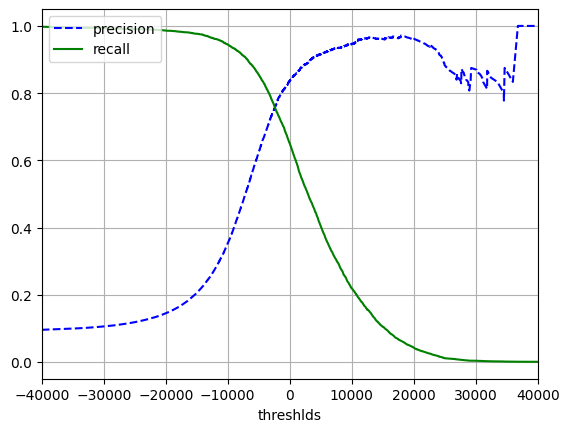

In [25]:
def plot_precision_recall_vs_threshold(precisions,recalls,threshlds):
    plt.plot(threshlds,precisions[:-1],'b--',label='precision')
    plt.plot(threshlds,recalls[:-1],'g-',label='recall')
    plt.xlim(-40000,40000)
    plt.gca()
    plt.grid(True)
    plt.legend(loc='upper left')
    plt.xlabel('threshlds')
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()


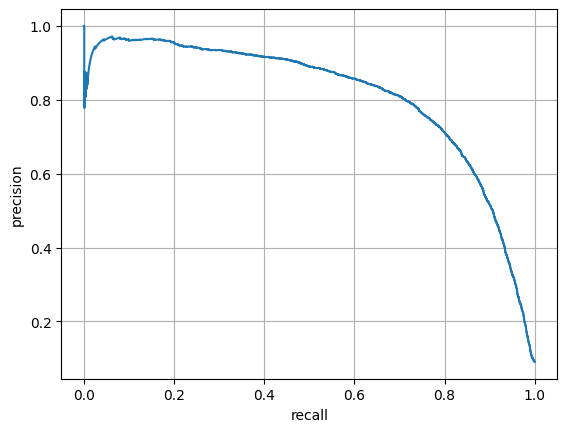

In [26]:
plt.plot(recalls,precisions)
plt.grid(True)
plt.xlabel('recall')
plt.ylabel('precision')
plt.show()

ROC CURVE


In [27]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_train_5,y_scores)

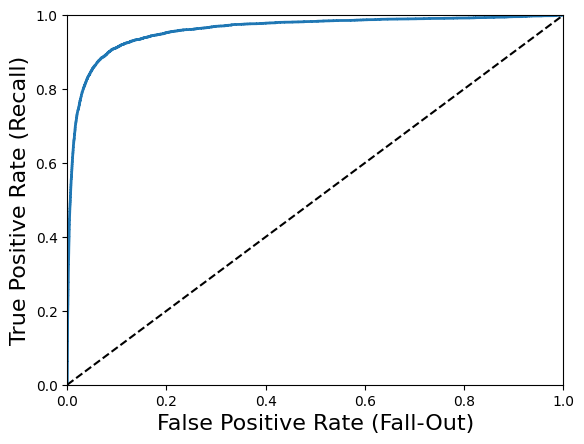

In [28]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
    plt.axis([0, 1, 0, 1])                                    # Not shown in the book
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) # Not shown
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.gca()
plot_roc_curve(fpr, tpr)
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

np.float64(0.9604938554008616)

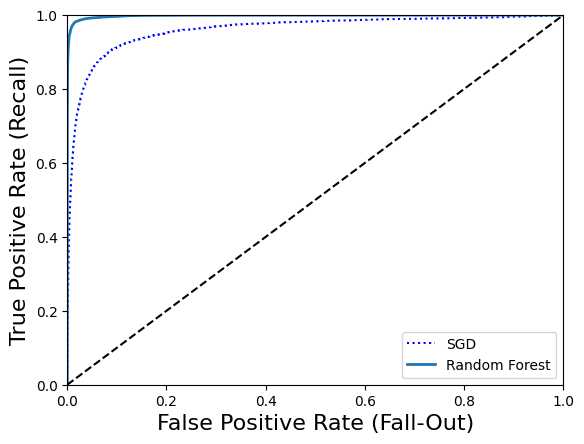

In [30]:
from sklearn.ensemble import RandomForestClassifier
forest_clf=RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
method="predict_proba")
y_scores_forest=y_probas_forest[:,1]
fpr_forest,tpr_forest,thresholds_forest=roc_curve(y_train_5,y_scores_forest)
plt.plot(fpr,tpr,'b:',label='SGD')
plot_roc_curve(fpr_forest,tpr_forest,'Random Forest')
plt.legend(loc='lower right')
plt.show()

In [31]:
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_probas_forest[:,1])

In [32]:
precisions,recalls,

(array([0.09035   , 0.15601796, 0.21697018, 0.2782198 , 0.3359375 ,
        0.39168474, 0.4434341 , 0.49221099, 0.53883011, 0.58103448,
        0.62384152, 0.65814579, 0.69354839, 0.72090213, 0.74856904,
        0.77310803, 0.79370733, 0.81468478, 0.83029737, 0.84566529,
        0.8605178 , 0.87232994, 0.88209825, 0.89121268, 0.90208833,
        0.90986159, 0.9178634 , 0.92464178, 0.93120086, 0.93672255,
        0.94127273, 0.94605505, 0.95223107, 0.95618941, 0.95927941,
        0.96257089, 0.96431961, 0.96689629, 0.96939365, 0.97113522,
        0.97292032, 0.975495  , 0.97634069, 0.9787572 , 0.98101519,
        0.98323571, 0.98412375, 0.98566455, 0.98719273, 0.98773389,
        0.98974681, 0.99050833, 0.99129327, 0.99186644, 0.99180858,
        0.99259582, 0.99340804, 0.99378606, 0.99440841, 0.99458239,
        0.99474526, 0.99514451, 0.99555659, 0.99622997, 0.99618594,
        0.99638031, 0.9965661 , 0.99652605, 0.99672462, 0.99692938,
        0.99688393, 0.99762031, 0.9981203 , 0.99

MULTICLASS CLASSIFICATION


In [41]:
from sklearn.svm import SVC
svm_clf=SVC()
svm_clf.fit(X_train,y_train)
svm_clf.predict([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [39]:
some_digit_scores=svm_clf.decision_function([some_digit])
some_digit_scores

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([[ 2.73719174,  6.20651629,  3.81372559,  9.32009109,  0.69223349,
         6.26207869, -0.31019599,  1.69984884,  8.29382546,  6.23989726]])

In [35]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [40]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf=OneVsRestClassifier(SVC())
ovr_clf.fit(X_train.values,y_train)
ovr_clf.predict([some_digit])
len(ovr_clf.estimators_)

10

In [42]:
ovr_clf.predict([some_digit])

array([3], dtype=uint8)

In [45]:
sgd_clf.fit(X_train.values,y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [47]:
y_train_pred=cross_val_predict(sgd_clf,X_train.values,y_train,cv=3)
conf_mx=confusion_matrix(y_train,y_train_pred)
conf_mx

array([[5635,    0,   61,   10,   16,   50,   46,    7,   66,   32],
       [   3, 6393,   95,   21,   16,   47,   15,   27,  109,   16],
       [  72,   56, 5174,   89,   69,   39,  163,   66,  212,   18],
       [  58,   32,  217, 4941,   23,  441,   32,   56,  216,  115],
       [  11,   26,   46,    6, 5298,   26,   73,   32,   87,  237],
       [  68,   23,   58,  150,   83, 4606,  174,   26,  152,   81],
       [  40,   13,   56,    6,   22,  113, 5625,    5,   36,    2],
       [  23,   24,  103,   36,  124,   40,   10, 5228,   75,  602],
       [  40,  101,  158,  122,   49,  457,   77,   35, 4666,  146],
       [  33,   18,   66,   83,  515,  127,    4,  485,  166, 4452]])

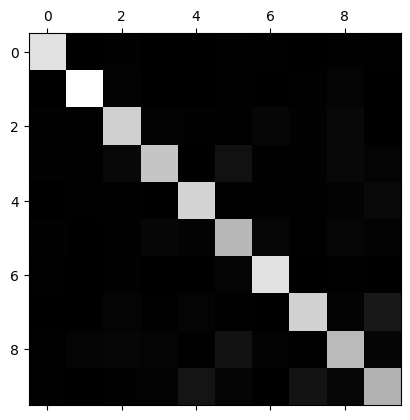

In [48]:
plt.matshow(conf_mx,cmap=plt.cm.gray)

In [56]:
noise =np.random.randint(0,100,(len(X_train),784))
X_train_mod=X_train +noise
noise=np.random.randint(0,100,(len(X_test),784))
X_test_mod=X_test+noise
y_train_mod=y_train
y_test_mod=y_test

In [51]:
X_test_mod

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
60000,4,10,92,27,23,97,84,92,58,76,...,86,12,44,55,38,84,11,66,70,72
60001,80,65,5,42,5,9,40,55,49,46,...,11,82,41,50,91,60,50,38,76,20
60002,51,20,5,60,59,34,91,8,12,6,...,61,16,63,62,37,29,27,78,69,62
60003,39,52,42,41,6,76,11,18,94,65,...,20,96,27,58,52,67,53,92,33,97
60004,15,92,51,1,40,86,7,17,52,35,...,56,7,43,0,40,82,32,5,73,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,16,29,60,63,42,24,43,12,55,0,...,29,35,79,85,29,84,97,3,18,99
69996,8,77,30,69,8,1,17,96,16,31,...,67,77,99,78,17,26,33,87,97,66
69997,60,76,71,47,36,33,8,91,77,44,...,84,41,5,76,55,93,57,58,19,15
69998,15,82,40,8,69,67,27,13,82,14,...,37,58,35,79,34,61,61,70,5,86


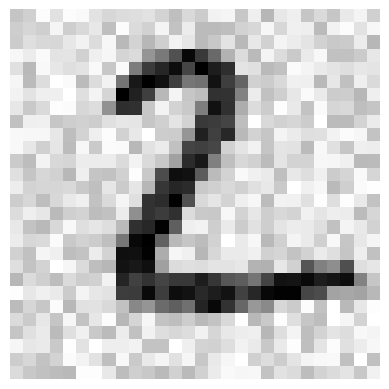

In [53]:

some_digi = X_test_mod.iloc[1]
some_digit_image = some_digi.values.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [57]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod.values,y_train_mod)
clean_digit=knn_clf.predict([some_digi])
clean_digit

array([2], dtype=uint8)